In [8]:
import sys

from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))


In [9]:
from src.data.load_data import load_ratings, load_movies
ratings = load_ratings()
movies = load_movies()

In [10]:
movies["genres"] = movies["genres"].fillna("")
movies["genres"] = movies["genres"].apply(lambda x: x.replace("|", " "))

In [11]:
# Reusing feature engineering from EDA stage
import re

def extract_year(title):
    matches = re.findall(r"\((\d{4})\)", title)
    for year in reversed(matches):
        year = int(year)
        if 1880 <= year <= 2025:
            return year
    return None

movies["year"] = movies["title"].apply(extract_year)

In [12]:
movies["title_clean"] = movies["title"].str.replace(r"\(\d{4}\)", "", regex=True).str.strip()
movies.head()

,movieId,title,genres,year,title_clean
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,1995.0,Toy Story
1,2,Jumanji (1995),Adventure Children Fantasy,1995.0,Jumanji
2,3,Grumpier Old Men (1995),Comedy Romance,1995.0,Grumpier Old Men
3,4,Waiting to Exhale (1995),Comedy Drama Romance,1995.0,Waiting to Exhale
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II


In [13]:
# Reusing feature engineering from EDA stage
import pandas as pd
def year_group(year):
    if pd.isna(year):
        return "unknown"
    elif year < 1990:
        return "old"
    elif year < 2005:
        return "classic"
    elif year < 2015:
        return "modern"
    else:
        return "new"

movies["year_group"] = movies["year"].apply(year_group)

## Content-based model
In this project, the Content-Based filtering component is intentionally kept lightweight and simplified.

The main goal of this section is **not to build a fully optimized content-based recommender system**, but to demonstrate how content signals (such as genres and release year) can be integrated into a **hybrid recommendation system together with collaborative filtering (SVD)**.

We do not perform deeper feature engineering such as: franchise or saga detection (e.g. Marvel series, sequels), advanced NLP on movie descriptions etc.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
# =========================
# Baseline Content Model
# (Genres only)
# =========================

tfidf_base = TfidfVectorizer()
tfidf_matrix_base = tfidf_base.fit_transform(movies["genres"])

cosine_sim_base = cosine_similarity(tfidf_matrix_base, tfidf_matrix_base)

indices = pd.Series(movies.index, index=movies["movieId"])

In [15]:
def get_similar_movies_base(movie_id, top_n=10):
    idx = indices[movie_id]

    sim_scores = list(enumerate(cosine_sim_base[idx]))
    sim_scores = [x for x in sim_scores if x[0] != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    top = sim_scores[:top_n]
    movie_indices = [i[0] for i in top]

    return movies.iloc[movie_indices][["movieId", "title", "genres"]]

In [16]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
# =========================
# Improved Content Model
# (Genres + Year Group)
# =========================

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["genres"])

encoder = OneHotEncoder()
year_matrix = encoder.fit_transform(movies[["year_group"]])

# optional weighting
tfidf_matrix = tfidf_matrix * 0.8
year_matrix = year_matrix * 0.2

final_matrix = hstack([tfidf_matrix, year_matrix])

cosine_sim = cosine_similarity(final_matrix, final_matrix)

In [17]:
def get_similar_movies(movie_id, top_n=10):
    idx = indices[movie_id]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = [x for x in sim_scores if x[0] != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    top = sim_scores[:top_n]
    movie_indices = [i[0] for i in top]

    return movies.iloc[movie_indices][["movieId", "title", "genres", "year_group"]]

In [18]:
def inspect_movie(movie_id):
    movie = movies[movies["movieId"] == movie_id]
    print(movie[["title", "genres", "year_group"]])

inspect_movie(1)

              title                                       genres year_group
0  Toy Story (1995)  Adventure Animation Children Comedy Fantasy    classic


In [19]:
def compare_recommendations(movie_id):
    print("🎬 BASELINE (Genres only)")
    display(get_similar_movies_base(movie_id))

    print("\n🎬 IMPROVED (Genres + Year)")
    display(get_similar_movies(movie_id))
compare_recommendations(1)

🎬 BASELINE (Genres only)


,movieId,title,genres
2209,2294,Antz (1998),Adventure Animation Children Comedy Fantasy
3027,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy
3663,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure Animation Children Comedy Fantasy
3922,4016,"Emperor's New Groove, The (2000)",Adventure Animation Children Comedy Fantasy
4790,4886,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy
10114,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure Animation Children Comedy Fantasy
10987,45074,"Wild, The (2006)",Adventure Animation Children Comedy Fantasy
11871,53121,Shrek the Third (2007),Adventure Animation Children Comedy Fantasy
13337,65577,"Tale of Despereaux, The (2008)",Adventure Animation Children Comedy Fantasy
18274,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure Animation Children Comedy Fantasy



🎬 IMPROVED (Genres + Year)


,movieId,title,genres,year_group
2209,2294,Antz (1998),Adventure Animation Children Comedy Fantasy,classic
3027,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy,classic
3663,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure Animation Children Comedy Fantasy,classic
3922,4016,"Emperor's New Groove, The (2000)",Adventure Animation Children Comedy Fantasy,classic
4790,4886,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy,classic
10114,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure Animation Children Comedy Fantasy,classic
24092,114240,Aladdin (1992),Adventure Animation Children Comedy Fantasy,classic
3312,3400,We're Back! A Dinosaur's Story (1993),Adventure Animation Children Fantasy,classic
4271,4366,Atlantis: The Lost Empire (2001),Adventure Animation Children Fantasy,classic
5573,5672,Pokemon 4 Ever (a.k.a. Pokémon 4: The Movie) (...,Adventure Animation Children Fantasy,classic


### 🖋️ Observation:

Baseline model retrieves movies that are highly similar in terms of genre,
but mixes different cinematic eras (e.g. modern CGI vs 90s animation).

After adding year_group:
- recommendations become more era-consistent
- but slightly reduce diversity in modern titles

Conclusion: Genres dominate similarity signal, while year_group acts as a weak contextual filter that biases recommendations toward temporal coherence.

Whether this is "better" depends on the definition of similarity:
- genre-based similarity → baseline is better
- era-consistent similarity → improved model is better


In [13]:
print("Genres only mean:", cosine_sim_base.mean())
print("Genres+year mean:", cosine_sim.mean())

Genres only mean: 0.18644312673508132
Genres+year mean: 0.195134962014177


In [14]:
diff = cosine_sim - cosine_sim_base
diff.mean()

0.008691835279096618

We observe a small increase in average cosine similarity
after adding year_group (+0.0087).

So:
- year_group introduces a measurable but weak signal
- it slightly reshapes the embedding space
- however, genre features remain the dominant factor


## 👁️‍🗨️Adding tags.csv

In [20]:
from src.data.load_data import load_tags

tags = load_tags()
tags.head()

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [21]:
movie_tags = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
)
movie_tags.columns = ["movieId", "user_tags"]
movie_tags.isnull().sum()

movieId      0
user_tags    0
dtype: int64

In [22]:
movies = movies.merge(movie_tags, on="movieId", how="left")
movies["user_tags"] = movies["user_tags"].fillna("")
movies["content"] = (movies["genres"] + " "
                     + movies["user_tags"])

In [23]:
# =========================
# Model
# (Genres + Tags)
# =========================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000)

tfidf_matrix_gt = tfidf.fit_transform(movies["content"])

cosine_sim_gt = cosine_similarity(tfidf_matrix_gt, tfidf_matrix_gt)
indices = pd.Series(movies.index, index=movies["movieId"])

In [24]:
def get_similar_movies_gt(movie_id, top_n=10):
    idx = indices[movie_id]

    sim_scores_gt = list(enumerate(cosine_sim_gt[idx]))
    sim_scores_gt = [x for x in sim_scores_gt if x[0] != idx]
    sim_scores_gt = sorted(sim_scores_gt, key=lambda x: x[1], reverse=True)

    top = sim_scores_gt[:top_n]
    movie_indices = [i[0] for i in top]

    return movies.iloc[movie_indices][["movieId", "title", "genres"]]

### ⚠️ Handling Missing Genre Information

During data exploration, we observed that not all movies have genre information available (e.g. "(no genres listed)").

As a result, we introduce a conditional hybrid approach:
- If genre information is available → we use a hybrid model combining:
  - Content-based similarity (TF-IDF on genres + year group)
  - Collaborative filtering (SVD)

- If genre information is missing → we avoid using content-based similarity, since it would not provide meaningful signal and could introduce noise (e.g. artificially high similarity between movies with no metadata)

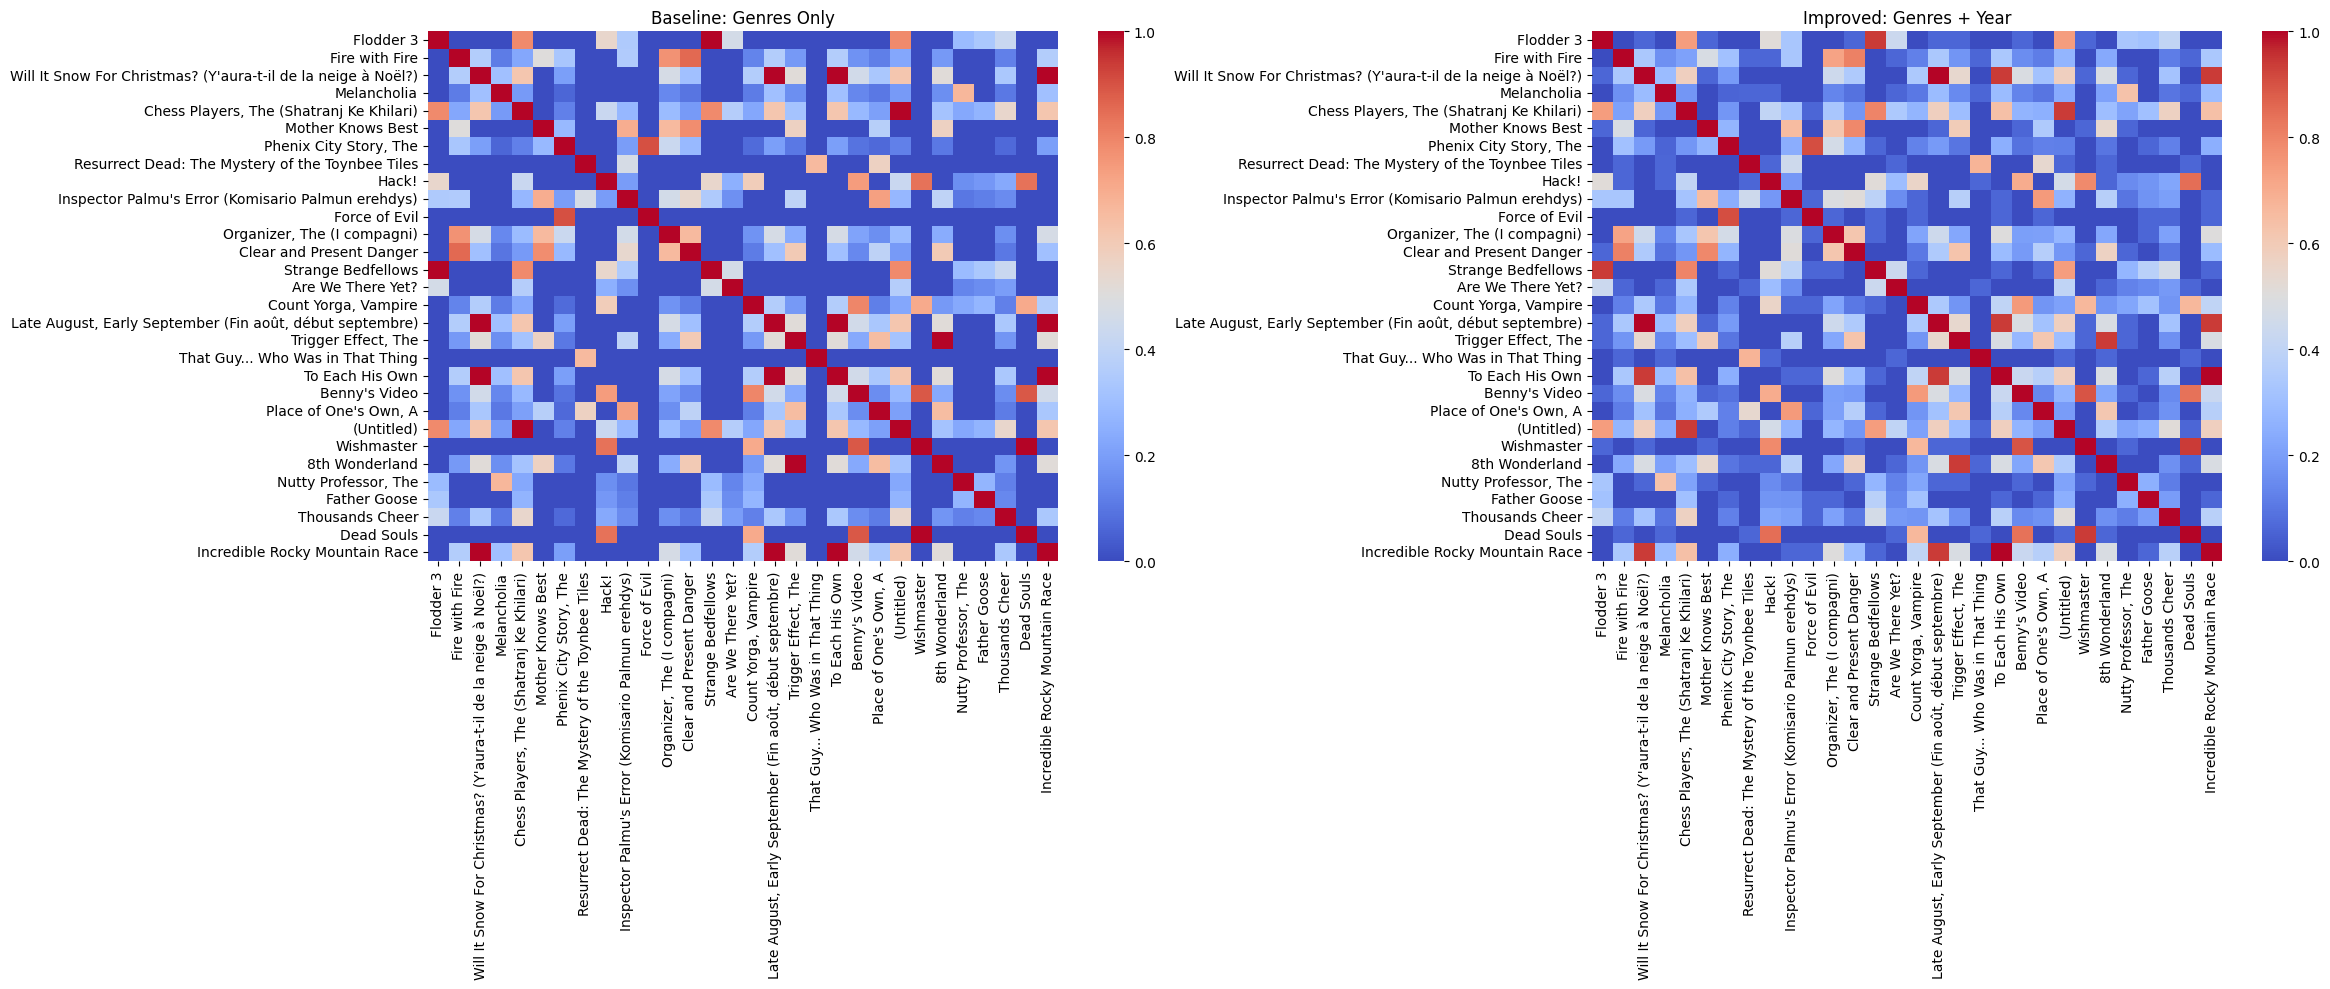

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

valid_movies = movies[movies["genres"] != "(no genres listed)"]
sample_size = 30
sample_df = valid_movies.sample(sample_size, random_state=42)

sample_indices = sample_df.index
sample_similarity_base = cosine_sim_base[np.ix_(sample_indices, sample_indices)]
sample_similarity_improved = cosine_sim[np.ix_(sample_indices, sample_indices)]
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(
    sample_similarity_base,
    cmap="coolwarm",
    xticklabels=sample_df["title_clean"],
    yticklabels=sample_df["title_clean"],
    ax=axes[0]
)
axes[0].set_title("Baseline: Genres Only")

sns.heatmap(
    sample_similarity_improved,
    cmap="coolwarm",
    xticklabels=sample_df["title_clean"],
    yticklabels=sample_df["title_clean"],
    ax=axes[1]
)
axes[1].set_title("Improved: Genres + Year")

plt.tight_layout()
plt.show()

The addition of year_group does not significantly reshape the similarity topology

❗ I decide to use ONLY genres as the content-based feature in the final hybrid model.

## SVD

In [13]:
from surprise import SVD, Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]],
    reader
)

In [14]:
def hybrid_predict(user_id, movie_id, svd_model, alpha=0.7):
    svd_pred = svd_model.predict(user_id, movie_id).est
    movie_idx = indices[movie_id]

    if not movies.loc[movie_idx, "has_genres"]:
        return svd_pred

    content_scores = cosine_sim[movie_idx]
    content_score = content_scores.mean()

    return alpha * svd_pred + (1 - alpha) * content_score

💡 SVD captures user–item interaction patterns   
Content-based component mitigates cold-start issues for items with few ratings   